<a href="https://colab.research.google.com/github/truptijadhav2008/Mobile-usage-engineering-feature-ex/blob/main/Copy_of_Mobile_usages_engineering_feature_Ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("mobile_usage_behavioral_analysis.csv")

In [ ]:
print(df.head())

   User_ID  Age  Gender  Total_App_Usage_Hours  Daily_Screen_Time_Hours  \
0        1   56    Male                   2.61                     7.15   
1        2   46    Male                   2.13                    13.79   
2        3   32  Female                   7.28                     4.50   
3        4   25  Female                   1.20                     6.29   
4        5   38    Male                   6.31                    12.59   

   Number_of_Apps_Used  Social_Media_Usage_Hours  \
0                   24                      4.43   
1                   18                      4.67   
2                   11                      4.58   
3                   21                      3.18   
4                   14                      3.15   

   Productivity_App_Usage_Hours  Gaming_App_Usage_Hours     Location  
0                          0.55                    2.40  Los Angeles  
1                          4.42                    2.43      Chicago  
2                      

In [ ]:
print(df.shape)

(1000, 10)


In [ ]:
print(df.isnull().sum())

User_ID                         0
Age                             0
Gender                          0
Total_App_Usage_Hours           0
Daily_Screen_Time_Hours         0
Number_of_Apps_Used             0
Social_Media_Usage_Hours        0
Productivity_App_Usage_Hours    0
Gaming_App_Usage_Hours          0
Location                        0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("Dataset cleaned successfully")

Dataset cleaned successfully


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Total_App_Usage_Hours         1000 non-null   float64
 4   Daily_Screen_Time_Hours       1000 non-null   float64
 5   Number_of_Apps_Used           1000 non-null   int64  
 6   Social_Media_Usage_Hours      1000 non-null   float64
 7   Productivity_App_Usage_Hours  1000 non-null   float64
 8   Gaming_App_Usage_Hours        1000 non-null   float64
 9   Location                      1000 non-null   object 
dtypes: float64(5), int64(3), object(2)
memory usage: 78.3+ KB
None


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   User_ID  Age  Gender  Total_App_Usage_Hours  Daily_Screen_Time_Hours  \
0        1   56       1                   2.61                     7.15   
1        2   46       1                   2.13                    13.79   
2        3   32       0                   7.28                     4.50   
3        4   25       0                   1.20                     6.29   
4        5   38       1                   6.31                    12.59   

   Number_of_Apps_Used  Social_Media_Usage_Hours  \
0                   24                      4.43   
1                   18                      4.67   
2                   11                      4.58   
3                   21                      3.18   
4                   14                      3.15   

   Productivity_App_Usage_Hours  Gaming_App_Usage_Hours  Location  
0                          0.55                    2.40         2  
1                          4.42                    2.43         0  
2                          1.71 

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.head())

    User_ID       Age    Gender  Total_App_Usage_Hours  \
0 -1.730320  1.416592  0.966559              -1.211402   
1 -1.726856  0.595617  0.966559              -1.364596   
2 -1.723391 -0.553748 -1.034598               0.279046   
3 -1.719927 -1.128430 -1.034598              -1.661408   
4 -1.716463 -0.061163  0.966559              -0.030533   

   Daily_Screen_Time_Hours  Number_of_Apps_Used  Social_Media_Usage_Hours  \
0                -0.147161             0.965493                  1.371742   
1                 1.641473             0.177657                  1.538547   
2                -0.860998            -0.741485                  1.475995   
3                -0.378821             0.571575                  0.502966   
4                 1.318226            -0.347567                  0.482115   

   Productivity_App_Usage_Hours  Gaming_App_Usage_Hours  Location  
0                     -1.348381               -0.052020 -0.053981  
1                      1.334144               -0.031

In [ ]:
print(df.describe())

print(df.corr(numeric_only=True))

          User_ID           Age        Gender  Total_App_Usage_Hours  \
count  1000.00000  1.000000e+03  1.000000e+03           1.000000e+03   
mean      0.00000  1.918465e-16 -6.927792e-17           7.283063e-17   
std       1.00050  1.000500e+00  1.000500e+00           1.000500e+00   
min      -1.73032 -1.703113e+00 -1.034598e+00          -1.725239e+00   
25%      -0.86516 -8.821376e-01 -1.034598e+00          -8.986312e-01   
50%       0.00000  1.030324e-01  9.665588e-01           1.574385e-02   
75%       0.86516  9.240073e-01  9.665588e-01           8.670861e-01   
max       1.73032  1.662885e+00  9.665588e-01           1.775876e+00   

       Daily_Screen_Time_Hours  Number_of_Apps_Used  Social_Media_Usage_Hours  \
count             1.000000e+03         1.000000e+03              1.000000e+03   
mean             -1.181277e-16         1.909584e-16              5.861978e-17   
std               1.000500e+00         1.000500e+00              1.000500e+00   
min              -1.801109e

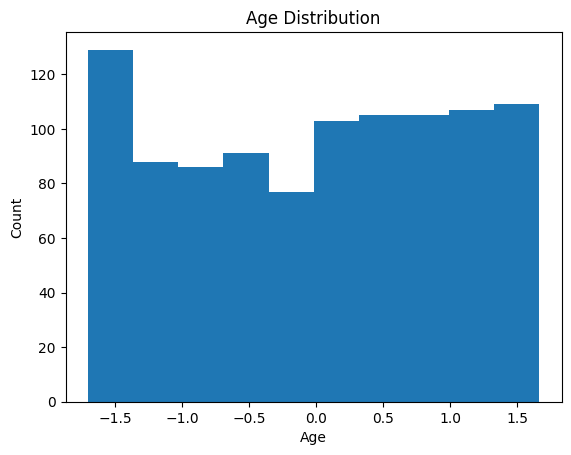

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

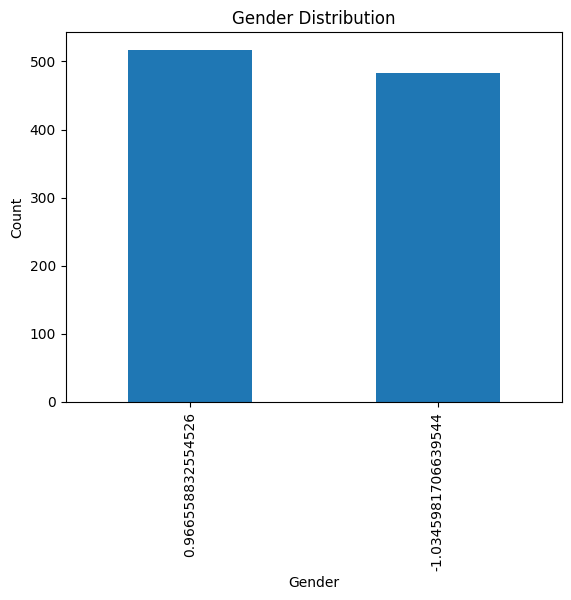

In [ ]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

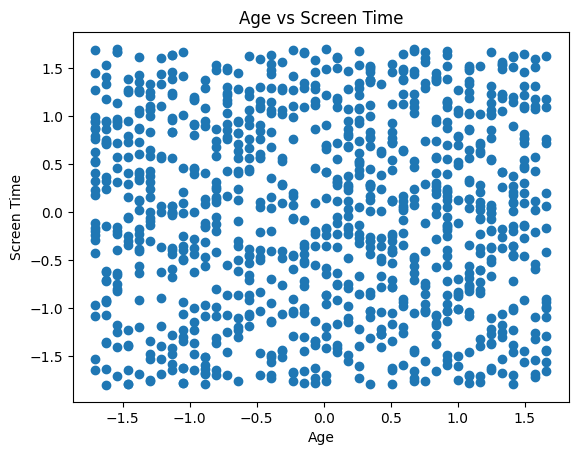

In [ ]:
plt.scatter(df['Age'],df['Daily_Screen_Time_Hours'])
plt.title('Age vs Screen Time')
plt.xlabel('Age')
plt.ylabel('Screen Time')
plt.show()

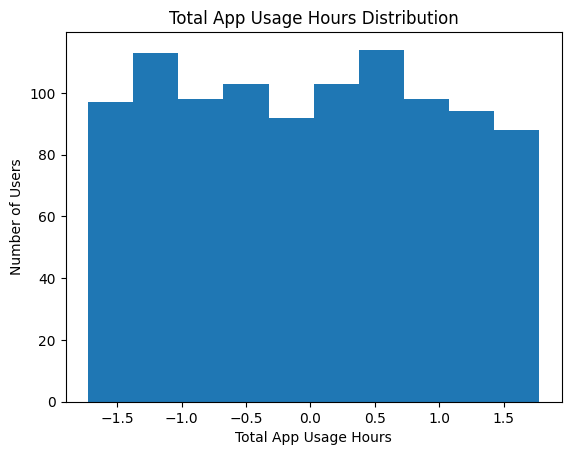

In [ ]:
plt.hist(df['Total_App_Usage_Hours'],bins=10)
plt.title('Total App Usage Hours Distribution')
plt.xlabel('Total App Usage Hours')
plt.ylabel('Number of Users')
plt.show()

Age Group
10-20   NaN
21-30   NaN
31-40   NaN
41-50   NaN
51-60   NaN
Name: Total_App_Usage_Hours, dtype: float64


/tmp/ipykernel_5346/1375308451.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_usage=df.groupby('Age Group')['Total_App_Usage_Hours'].mean()


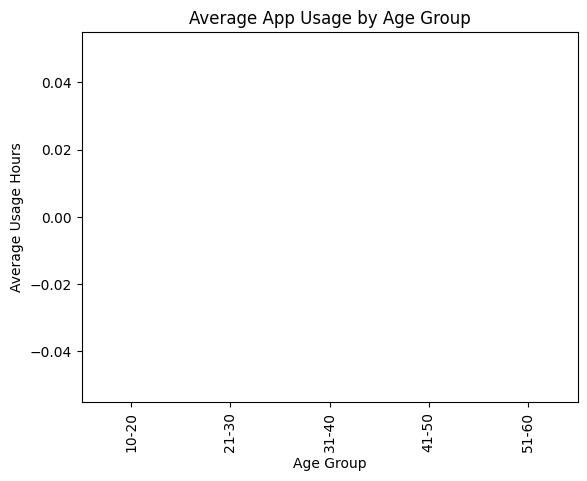

In [ ]:
df['Age Group']=pd.cut(df['Age'],bins=[10,20,30,40,50,60],
labels=['10-20','21-30','31-40','41-50','51-60'])
age_group_usage=df.groupby('Age Group')['Total_App_Usage_Hours'].mean()
print(age_group_usage)
age_group_usage.plot(kind='bar')
plt.title('Average App Usage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Usage Hours')
plt.show()

Age Group
Very Young    0.049446
Young        -0.030697
Adult        -0.033807
Senior        0.035410
Name: Total_App_Usage_Hours, dtype: float64


/tmp/ipykernel_5346/860706556.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_usage = df.groupby('Age Group')['Total_App_Usage_Hours'].mean()


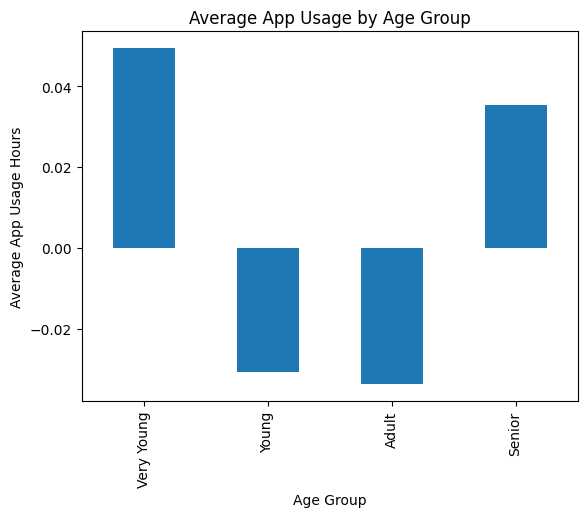

In [ ]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[-2, -1, 0, 1, 2],
    labels=['Very Young', 'Young', 'Adult', 'Senior']
)

age_group_usage = df.groupby('Age Group')['Total_App_Usage_Hours'].mean()

print(age_group_usage)

age_group_usage.plot(kind='bar')
plt.title('Average App Usage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average App Usage Hours')
plt.show()